<a href="https://colab.research.google.com/github/ngzhiwei517/DSP-Group-4/blob/main/SC3021_Group_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Group 4 (FDAE)

1. HAU JIA QI
2. NG ZHI WEI
3. TOH EN QI

# **How does Air Quality and Distance to Public Facilities Affect Property Prices in Singapore?**

## **Introduction**


For Singaporeans, housing is not merely a means of material shelter, but also something they strive for throughout their lives, and in a sense, a source of emotional support. Naturally, fluctuations in housing prices are a constant concern in their daily lives. Whether they are working hard to buy a home or considering selling or renting it out, price increases are crucial. Our group has observed these price fluctuations, but the reasons behind them remain unknown. Therefore, we intend to explore and compare the innfluence of these two factors -- air quality and access to key facilities -- on HDB resale prices.

Given the limited land area, most housing in Singapore is in the form of high-rise apartments, primarily HDB flats. The Housing & Development Board (HDB) in Singapore is the national public housing authority responsible for providing affordable and quality housing to the nation's residents.

## **Deriving the Problem Statement**

In Singapore, the majority of people live in HDB flats, which are public housing units provided by the Housing and Development Board (HDB). Approximately 77.4% of residents live in HDB flats, with the most common type being four-room flats. In exploring the factors contributing to rising housing prices in Singapore,we focus on two potential drivers: locational amenities and environmental quality.
1. Air Quality: Singapore's air quality varies significantly across different regions and at different times due to factors such as cross-border smog, industrial activities, and traffic patterns.According to WHO research, air pollutants (PM2.5, PM10, nitrogen dioxide, etc.) can have serious health effects.

2. Access to Facilities: In real estate pricing, distance to public facilities (such as MRT stations, hospitals, and schools) is generally considered a significant factor influencing property prices. Generally speaking, residences closer to major transportation hubs or amenities tend to be more popular with homebuyers due to shorter commutes and greater convenience, potentially resulting in higher transaction prices.

This report primarily explores how differences in air quality across different areas of Singapore and proximity to facilities affect the price of HDB flats.


## **Hypothesis/Analysis Goal (Ask)**


In this report, we hypothesize that even if Singapore's air quality remains within safe limits, regional differences in air quality are correlated with HDB resale prices. We also assume that HDB flats located closer to key public facilities (such as MRT stations, hospitals, and schools) tend to command higher resale prices due to greater accessibility and convenience. In summary, this descriptive and correlational analysis will explore the following questions:

1. Do areas with persistently high PSI/PM2.5 levels exhibit lower HDB resale prices?

2. How does accessibility to key amenities (MRT/LRT stations, shopping centres, schools, healthcare) relate to resale prices?

3. What is the relative contribution of environmental and accessibility factors compared to traditional housing attributes (flat size, storey range, remaining lease) in explaining price variation?

Through detailed analysis of these questions, we hope to gain a more comprehensive understanding of the potential impact of air quality and distances on Singapore's HDB resale market. The goal is to quantify the relative contribution of environmental and accessibility factors in explaining HDB resale prices, beyond traditional housing attributes.

Meanwhile, this is primarily a regression and exploratory analysis problem, where resale price is the target variable and air quality, accessibility measures, and housing characteristics are explanatory variables.
Model performance will be evaluated using standard hypothesis testing and prediction metrics, including:

* R-squared: proportion of price variation explained by the model
* Mean Squared Error (MSE): predictive accuracy of resale price estimates



## **Data Source identification and Exploration (Prepare)**

###Requirement analysis:

To solve the problem, we would need the following data:
1. Historical data on the resale prices of HDB flats in various towns of Singapore over the years
    - identifying trends and how environmental and accessibility factors affects the price
2. Historical Pollutant Standards Index (PSI) over the years
    - understanding the air quality of different regions and how it might affect the flat price
3. Characteristics of the flats (eg. flat type, storey range and remaining leasing)
    - analysing how traditional housing attributes affects the flat price
4. Locations of amenities (MRT and LRT, hospitals and schools)
    - using the proximity of such amenities to the flats to analyse its influence on flat prices
5. Region in which the town is located
    - North, South, East, West, Central
    - to match the towns with the regions, allowing for comparisons between various flats

We will be analysing and linking the data by town (eg. Jurong East, Boon Lay), with the exception of the PSI data as such data are region-based. Hence, other than knowing the towns of the various HDB flats, identifying the region is needed, to link the price of resale flats with the air quality.


To ensure a comprehensive analysis, we have chosen datasets that covers a range of years and locations. In the attempt to reflect the current resale flat market and make relevent decisions,
we will be using data from 2021 to 2024. This is also the period after the COVID-19 pandemic, when some preference and priorities may have shifted.

Given that housing purchase decisions are influenced by longer-term environmental conditions rather than short-term fluctuations, air quality data will be aggregated at the monthly level.

###List of considered sources:

We mark the final source selection datasets with an *.

* **Property Price Data**
* [Resale Flat Prices (Based on Registration Date) from Jan 2017 onwards(DS1)*](https://data.gov.sg/datasets/d_8b84c4ee58e3cfc0ece0d773c8ca6abc/view )


* **Air Quality Data**
* [Historical Pollutant Standards Index (PSI) 2021 (DS2)*](https://data.gov.sg/datasets/d_05b35c51664e1bb6f4dcd78478ae1abe/view)
* [Historical Pollutant Standards Index (PSI) 2022 (DS3)*](https://data.gov.sg/datasets/d_d3fb32451d63dc48dc425146ec014516/view)
* [Historical Pollutant Standards Index (PSI) 2023 (DS4)*](https://data.gov.sg/datasets/d_10501b71361f97dbbbab82095406c9c5/view)
* [Historical Pollutant Standards Index (PSI) 2024 (DS5)*](https://data.gov.sg/datasets/d_9213cd2e4631f7148ab5932a10df9958/view)

* **Location/Amenities Data**
* [Singapore Train Station Coordinates (DS6)*](https://www.kaggle.com/datasets/yxlee245/singapore-train-station-coordinates)
* [Hospitals with Coordinates (DS7)](https://www.kaggle.com/datasets/muhdirshath/hospitals-in-singapore)

* **Education Amenities**
* [General information of schools (DS8)*](https://data.gov.sg/datasets/d_688b934f82c1059ed0a6993d2a829089/view)

* **Geographic Mapping Data**
* [Singapore City Geo-Coordinates (DS9)*](https://www.kaggle.com/datasets/shymammoth/singapore-city-geo-coordinates-more-reliable)

##Data Exploration

In the following, we explored and justified for the selection of each dataset.

## DS1: Resale Flat Prices (Based on Registration Date), Jan 2021 – Dec 2024

**Description**:
This dataset was extracted from Singapore's open data portal, data.gov.sg, and contains HDB resale flat transaction records from January 2017 onwards. It includes key attributes such as the transaction month, town, flat type, block, street name, storey range, floor area (sqm), flat model, lease commencement date, remaining lease, and resale price — covering all the housing characteristics we identified as requirements in our problem formulation.

This dataset directly addresses our core requirement of having historical resale price data across different towns in Singapore. The town column allows us to link resale prices to specific locations, which is essential for comparing prices across regions and eventually joining with our air quality and amenity datasets.

Although the dataset spans from January 2017 onwards, for our analysis we will be filtering to 2021–2024 during the data preparation stage. This allows us to focus on the post-COVID period, where housing preferences and priorities may have shifted, and to align with the time range of our PSI air quality data.

### Step 1: Load and preview the dataset

We first load the dataset using pandas and preview the first few rows to understand its structure and ensure that the data has been loaded correctly.

In [ ]:
import pandas as pd

# Load dataset
resale = pd.read_csv('/content/Resale flat price 2017-26.csv')

# Preview top 5 rows
resale.head()

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
0,2017-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0
1,2017-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0
2,2017-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,262000.0
3,2017-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,265000.0
4,2017-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,265000.0


This step allows us to verify that the dataset has been imported successfully and to observe the format of each column. Next, we examine the structure of the dataset to understand the number of rows, columns, and data types.

### Step 2: Check shape and column info

In [ ]:
# Check number of rows, columns and data types
resale.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 224000 entries, 0 to 223999
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   month                224000 non-null  object 
 1   town                 224000 non-null  object 
 2   flat_type            224000 non-null  object 
 3   block                224000 non-null  object 
 4   street_name          224000 non-null  object 
 5   storey_range         224000 non-null  object 
 6   floor_area_sqm       224000 non-null  float64
 7   flat_model           224000 non-null  object 
 8   lease_commence_date  224000 non-null  int64  
 9   remaining_lease      224000 non-null  object 
 10  resale_price         224000 non-null  float64
dtypes: float64(2), int64(1), object(8)
memory usage: 18.8+ MB


The dataset contains 224,000 entries and 11 columns. Most columns are stored as object types (categorical information such as town, flat type, and street name), while numerical variables such as floor_area_sqm and resale_price are stored as float values. The lease_commence_date column is stored as an integer representing the year the lease started.

This step helps confirm that the dataset contains the expected variables and that the data types are appropriate for further analysis. We then check for missing values across all columns to ensure data completeness.

### Step 3:Check for missing values

In [ ]:
# Count missing values per column
resale.isnull().sum()

,0
month,0
town,0
flat_type,0
block,0
street_name,0
storey_range,0
floor_area_sqm,0
flat_model,0
lease_commence_date,0
remaining_lease,0


The results show that all columns contain zero missing values, indicating that the dataset is complete and does not require imputation or data cleaning for missing entries. Next, we examine the number of distinct values in each column to understand the diversity of the data. This information helps us understand how categorical variables are distributed and whether they are suitable for grouping or aggregation during analysis.

### Step 4: Cardinalities — distinct values per column

In [ ]:
# Check number of unique values per column
resale.nunique()

,0
month,109
town,26
flat_type,7
block,2748
street_name,576
storey_range,17
floor_area_sqm,187
flat_model,21
lease_commence_date,56
remaining_lease,696


The dataset spans 109 distinct months, confirming broad temporal coverage. There are 26 unique towns, aligning well with our requirement to compare resale prices across different locations in Singapore. resale_price has 4,576 distinct values, reflecting the wide continuous variation expected of a regression target variable. storey_range has only 17 distinct categories, and flat_type just 7 — both of which can be treated as ordinal or categorical features after numeric extraction and encoding

### Step 5: Summary statistics

In [ ]:
# Summary statistics for numeric columns
resale.describe()

,floor_area_sqm,lease_commence_date,resale_price
count,224000.000000,224000.000000,2.240000e+05
mean,96.751149,1996.455982,5.255811e+05
std,24.015345,14.310548,1.871231e+05
min,31.000000,1966.000000,1.400000e+05
25%,81.000000,1985.000000,3.860750e+05
50%,93.000000,1997.000000,4.950000e+05
75%,112.000000,2012.000000,6.300000e+05
max,366.700000,2021.000000,1.658888e+06


The average resale price is approximately SGD 525,581, with values ranging widely from SGD 140,000 to SGD 1,658,888. This large spread — with a standard deviation of SGD 187,123 — suggests that resale prices are heavily influenced by multiple factors, motivating our multivariate regression approach. floor_area_sqm ranges from 31 to 366.7 sqm with a mean of 96.75 sqm, consistent with typical HDB flat sizes. lease_commence_date spans from 1966 to 2021, reflecting the mix of older and newer flats across the dataset. We next examine the distribution of resale transactions across towns.

### Step 6: Distribution of resale transactions by town

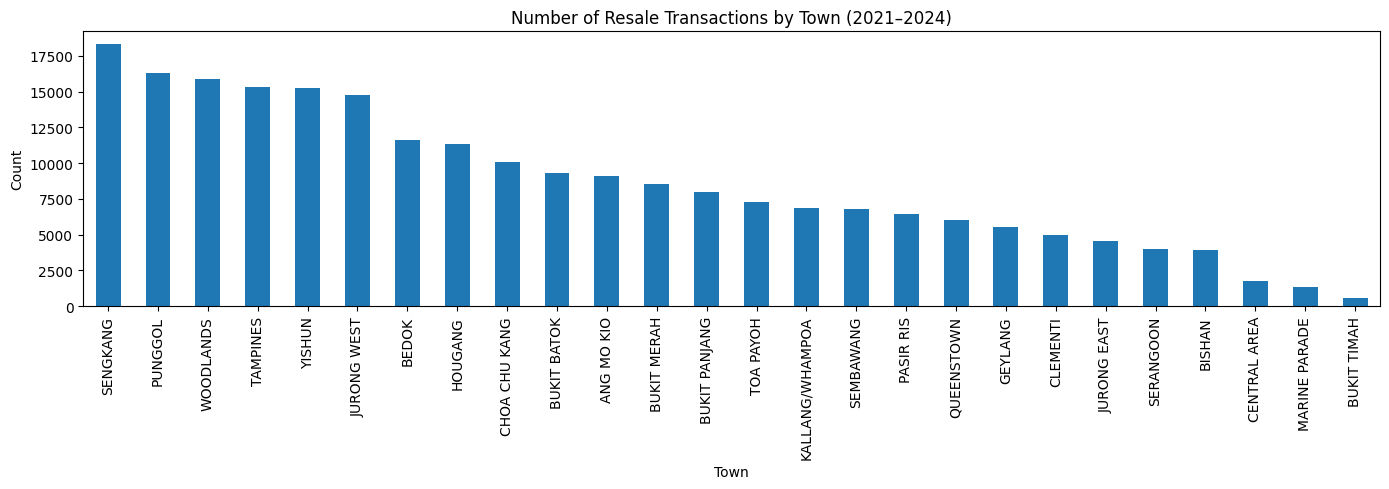

In [ ]:
import matplotlib.pyplot as plt

resale['town'].value_counts().plot(kind='bar', figsize=(14,5), title='Number of Resale Transactions by Town (2021–2024)')
plt.xlabel('Town')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

The chart shows that towns such as Sengkang, Punggol, Woodlands, Tampines, and Yishun have the highest number of resale transactions between 2021 and 2024. In contrast, towns such as Bukit Timah, Marine Parade, and Central Area have significantly fewer transactions.

This distribution likely reflects differences in housing supply and population density across towns, as well as the number of available HDB flats in each location. Next,we examine how resale prices vary across different storey ranges.

### Step 7: Storey range vs average resale price

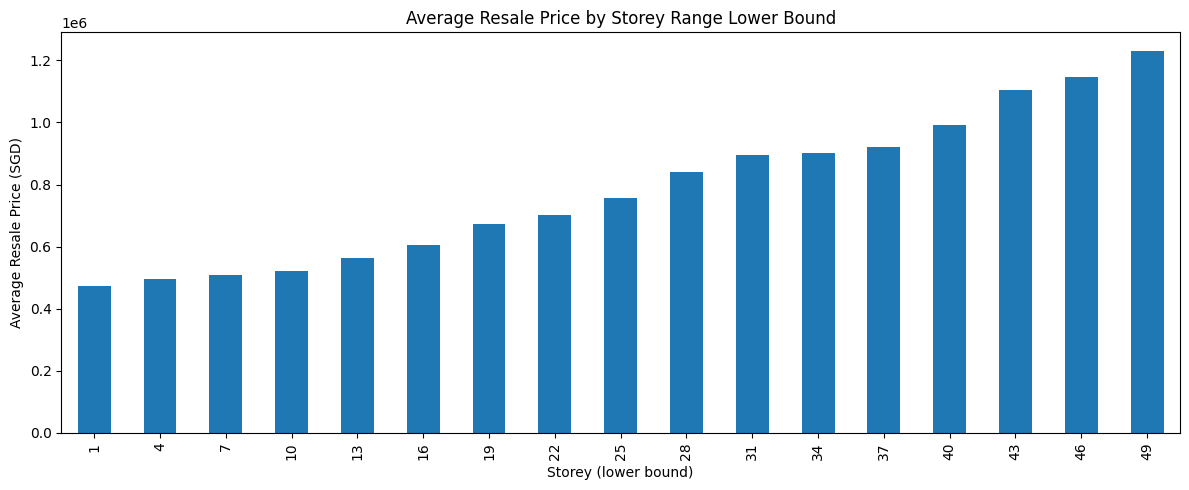

In [ ]:
# Extract storey lower bound for ordering
resale['storey_low'] = resale['storey_range'].str.split(' TO ').str[0].astype(int)

resale.groupby('storey_low')['resale_price'].mean().plot(
    kind='bar', figsize=(12,5),
    title='Average Resale Price by Storey Range Lower Bound'
)
plt.xlabel('Storey (lower bound)')
plt.ylabel('Average Resale Price (SGD)')
plt.tight_layout()
plt.show()

The results show a clear upward trend, where flats located on higher storeys tend to have higher average resale prices. This may be due to several factors, such as better views, reduced noise, improved ventilation, and stronger buyer preferences for higher-floor units.

This relationship suggests that storey level is an important housing characteristic influencing resale prices, and it may be included as a relevant feature in further analysis. Next, we examine the relationship between flat type and the average resale price.

### Step 8: Flat type vs average resale price

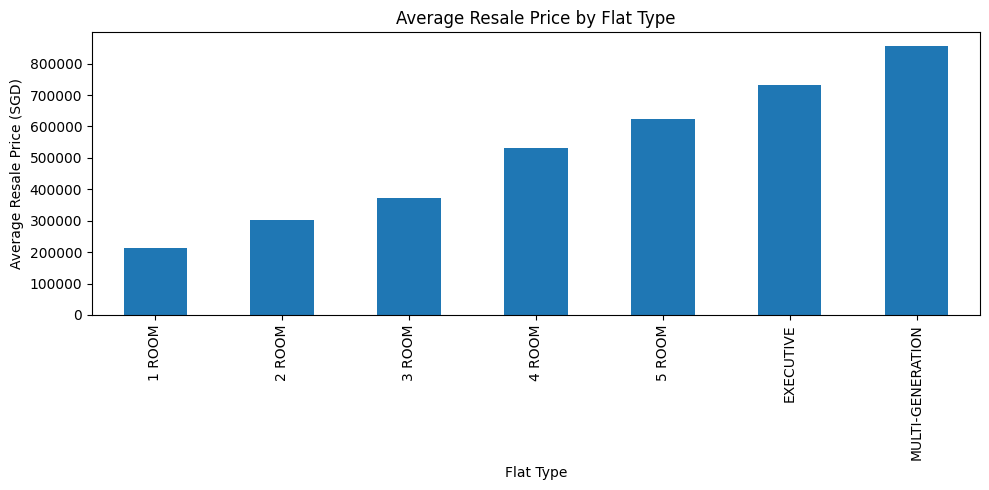

In [ ]:
resale.groupby('flat_type')['resale_price'].mean().sort_values().plot(
    kind='bar', figsize=(10,5),
    title='Average Resale Price by Flat Type'
)
plt.xlabel('Flat Type')
plt.ylabel('Average Resale Price (SGD)')
plt.tight_layout()
plt.show()

The chart shows a clear upward trend in average resale prices as the flat type increases in size. Smaller flats such as 1-room and 2-room units have the lowest average resale prices, while larger units such as Executive and Multi-Generation flats have significantly higher average prices.

For example, 1-room flats have an average resale price of approximately SGD 210,000, while Multi-Generation flats exceed SGD 850,000 on average. This pattern is expected because larger flats typically offer more living space and rooms, making them more suitable for larger households.Additionally, larger flat types tend to be less common and may be located in more mature towns, which can also contribute to higher resale values.

Overall, this analysis suggests that flat type is a strong determinant of resale price, and it will likely be an important variable when analysing housing price variations across different towns in Singapore.

### Step 9: Remaining lease vs average resale price

Last, we analyse the relationship between remaining lease and the average resale price of HDB flats. Remaining lease refers to the number of years left on the flat’s lease and is an important factor influencing housing value.

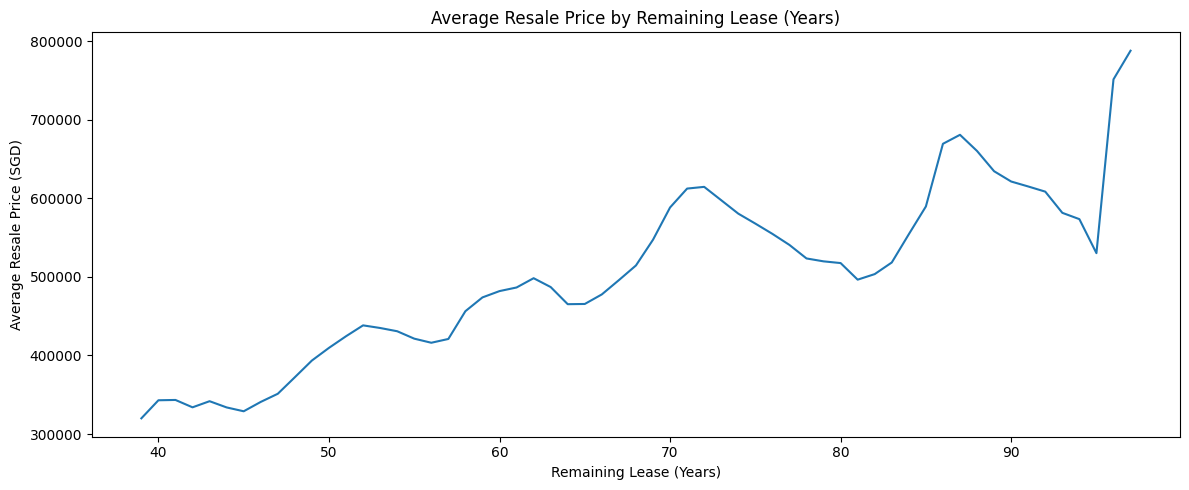

In [ ]:
# Extract numeric years from remaining_lease string e.g. "61 years 04 months"
resale['remaining_lease_years'] = resale['remaining_lease'].str.extract(r'(\d+)\s*year').astype(float)

resale.groupby('remaining_lease_years')['resale_price'].mean().plot(
    figsize=(12,5),
    title='Average Resale Price by Remaining Lease (Years)'
)
plt.xlabel('Remaining Lease (Years)')
plt.ylabel('Average Resale Price (SGD)')
plt.tight_layout()
plt.show()

The chart shows a generally increasing trend, where flats with longer remaining leases tend to have higher average resale prices. Flats with around 40 years of remaining lease have lower average prices, while flats with 90 years or more remaining lease have significantly higher prices.This suggests that remaining lease is an important factor affecting resale prices, as buyers typically prefer flats with longer lease durations.

### Data Quality Assessment

**Positively assessed** — Completeness and source reliability: The dataset contains 224,000 entries with zero missing values across all 11 columns, indicating that all variables are fully recorded. As the dataset is obtained from data.gov.sg, Singapore's official open data portal maintained by the government, it is expected to meet high standards of reliability and accuracy, making it a trustworthy source for our analysis.


**Problematically assessed** — String-encoded numerical columns requiring extraction: Several columns that are analytically important are stored as strings rather than usable numeric values. The storey_range column is stored in the format "10 TO 12", and remaining_lease is stored as "61 years 04 months" — both requiring regex extraction before they can be used as numeric features in our regression model. Additionally, the month column is stored as a string in "YYYY-MM" format and will need to be converted to datetime. These formatting issues must be resolved during data structuring before any meaningful analysis can be performed.

### Conclusion

DS1 is the core dataset of our analysis, providing comprehensive HDB resale transaction records across Singapore from 2017 to 2026. It is complete, reliable and directly addresses our requirement for historical resale price data across different towns. Key points for subsequent steps:


**Data Structuring:**

* Filter rows to retain only 2021–2024 transactions, aligning with our PSI air quality data time range
* Convert month from string to datetime format and extract year and month_num as separate columns
Extract numeric storey lower bound from storey_range (e.g. "10 TO 12" → 10) using string splitting
* Extract numeric remaining lease years from remaining_lease (e.g. "61 years 04 months" → 61) using regex
* Drop columns not needed for analysis: block, street_name, flat_model



**Data Enriching:**

* The town column will serve as the primary join key to link resale transactions with school count from DS8, nearest MRT distance computed using DS6 and DS9, and PSI region mapping from DS9
* Each transaction will be tagged with its corresponding monthly PSI and PM2.5 readings by matching town → region (via DS9) and year-month (via DS2–DS5)

## DS2–DS5: Historical Pollutant Standards Index (PSI), 2021–2024

**Description:** The PSI datasets were extracted from Singapore's open data portal, data.gov.sg. Four separate annual datasets were used — covering 2021, 2022, 2023 and 2024 — as the data is published year by year. Each dataset contains hourly pollutant readings across five regions in Singapore (North, South, East, West and National), with measurements including PM2.5, PM10, ozone (O3), carbon monoxide (CO), sulphur dioxide (SO2), nitrogen dioxide (NO2), and the overall PSI index. This directly addresses our requirement for air quality data across different regions of Singapore over the 2021–2024 period.

Since housing purchase decisions are influenced by longer-term environmental conditions rather than short-term fluctuations, we will be aggregating the PSI readings to the monthly level during data structuring. We will also retain only the four regional readings (North, South, East, West, Central). Additionally, region_id will be dropped as it is simply a coded duplicate of the region column (e.g. rSO = South) and adds no analytical value.

### Step 1: Load and preview the datasets

We first load the PSI datasets and preview the first few rows to understand their structure and confirm that the data has been imported correctly. Each dataset contains hourly air quality readings across different regions in Singapore, including pollutants such as PM2.5, PM10, ozone (O₃), carbon monoxide (CO), sulphur dioxide (SO₂), nitrogen dioxide (NO₂), and the overall PSI index.

In [ ]:
import pandas as pd

# Load all four PSI datasets
psi_2021 = pd.read_csv('/content/HistoricalPollutantStandardsIndexPSI2021.csv')
psi_2022 = pd.read_csv('/content/HistoricalPollutantStandardsIndexPSI2022.csv')
psi_2023 = pd.read_csv('/content/HistoricalPollutantStandardsIndexPSI2023.csv')
psi_2024 = pd.read_csv('/content/HistoricalPollutantStandardsIndexPSI2024 (1).csv')

# Combine into one dataframe
psi = pd.concat([psi_2021, psi_2022, psi_2023, psi_2024], ignore_index=True)

# Preview top 5 rows
psi.head()

,date,timestamp,update_timestamp,region,region_id,location_longitude,location_latitude,pm10_twenty_four_hourly,pm10_sub_index,pm25_twenty_four_hourly,pm25_sub_index,o3_eight_hour_max,o3_sub_index,co_eight_hour_max,co_sub_index,so2_sub_index,so2_twenty_four_hourly,no2_one_hour_max,psi_twenty_four_hourly,psi_three_hourly
0,2021-01-01,2021-01-01T00:00:00+08:00,2021-01-01T00:08:52+08:00,south,rSO,103.82,1.29587,31.0,31.0,16.0,55.0,32.0,14.0,0.71,7.0,3.0,4.0,14.0,55.0,NaN
1,2021-01-01,2021-01-01T00:00:00+08:00,2021-01-01T00:08:52+08:00,north,rNO,103.82,1.41803,28.0,28.0,13.0,52.0,51.0,21.0,0.51,5.0,2.0,3.0,3.0,52.0,NaN
2,2021-01-01,2021-01-01T00:00:00+08:00,2021-01-01T00:08:52+08:00,east,rEA,103.94,1.35735,36.0,36.0,16.0,55.0,35.0,15.0,0.58,6.0,2.0,3.0,10.0,55.0,NaN
3,2021-01-01,2021-01-01T00:00:00+08:00,2021-01-01T00:08:52+08:00,central,rCE,103.82,1.35735,29.0,29.0,12.0,50.0,22.0,9.0,0.38,4.0,2.0,3.0,8.0,50.0,NaN
4,2021-01-01,2021-01-01T00:00:00+08:00,2021-01-01T00:08:52+08:00,west,rWE,103.70,1.35735,25.0,25.0,9.0,37.0,14.0,6.0,0.53,5.0,3.0,6.0,17.0,37.0,NaN


Next, we examine the dataset structure to understand the number of rows, columns, and data types.

### Step 2: Check shape and column info

In [ ]:
psi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202158 entries, 0 to 202157
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   date                     202158 non-null  object 
 1   timestamp                202158 non-null  object 
 2   update_timestamp         202158 non-null  object 
 3   region                   202158 non-null  object 
 4   region_id                202158 non-null  object 
 5   location_longitude       202158 non-null  float64
 6   location_latitude        202158 non-null  float64
 7   pm10_twenty_four_hourly  191979 non-null  float64
 8   pm10_sub_index           191979 non-null  float64
 9   pm25_twenty_four_hourly  191979 non-null  float64
 10  pm25_sub_index           191979 non-null  float64
 11  o3_eight_hour_max        191929 non-null  float64
 12  o3_sub_index             191710 non-null  float64
 13  co_eight_hour_max        161071 non-null  float64
 14  co_s

The dataset contains 202,158 entries and 20 columns, with most pollutant measurements stored as float values and time-related variables stored as object types. Columns such as pm10_twenty_four_hourly, pm25_twenty_four_hourly, o3_eight_hour_max, and psi_twenty_four_hourly represent numerical air quality measurements.

This step confirms that the dataset includes the expected pollutant indicators required for analysing air quality trends across regions in Singapore. Next, we check for missing values across all columns.

### Step 3: Check for missing values

In [ ]:
psi.isnull().sum()

,0
date,0
timestamp,0
update_timestamp,0
region,0
region_id,0
location_longitude,0
location_latitude,0
pm10_twenty_four_hourly,10179
pm10_sub_index,10179
pm25_twenty_four_hourly,10179


The results show that several pollutant variables contain missing values, particularly co_eight_hour_max and other pollutant measurements. The column psi_three_hourly contains entirely missing values, indicating that it was not recorded in this dataset.

Since the psi_twenty_four_hourly column already provides a comprehensive indicator of overall air quality, the psi_three_hourly column will be removed during data cleaning as it does not provide useful analytical information.

### Step 4: Cardinalities — distinct values per column

In [ ]:
psi.nunique()

,0
date,1429
timestamp,33693
update_timestamp,33693
region,6
region_id,6
location_longitude,4
location_latitude,4
pm10_twenty_four_hourly,212
pm10_sub_index,187
pm25_twenty_four_hourly,159


The dataset spans 1,429 distinct dates, covering air quality readings from 2021 to 2024. The region column contains six categories, representing the geographical regions where air quality is monitored.

**Pollutant measurement variables contain a large number of distinct values, reflecting the continuous variation expected in environmental data.** This confirms that the dataset provides sufficient variability for analysing air quality patterns across regions and time.

### Step 5: Summary statistics

In [ ]:
psi.describe()

,location_longitude,location_latitude,pm10_twenty_four_hourly,pm10_sub_index,pm25_twenty_four_hourly,pm25_sub_index,o3_eight_hour_max,o3_sub_index,co_eight_hour_max,co_sub_index,so2_sub_index,so2_twenty_four_hourly,no2_one_hour_max,psi_twenty_four_hourly,psi_three_hourly
count,202158.000000,202158.000000,191979.000000,191979.000000,191979.000000,191979.000000,191929.000000,191710.000000,161071.000000,191929.000000,191979.000000,191979.000000,191869.000000,191979.000000,0.0
mean,86.516667,1.130992,26.104838,26.074574,11.865214,44.235305,24.168458,10.260395,0.566866,4.997792,3.173060,5.101626,25.545436,44.184711,NaN
std,38.691587,0.507024,9.050904,8.912268,4.968354,12.164375,16.732579,7.151491,0.241644,1.868293,2.560246,4.089767,15.783443,12.147101,NaN
min,0.000000,0.000000,5.000000,5.000000,2.000000,7.000000,1.000000,0.715482,0.060000,1.000000,1.000000,1.000000,1.000000,12.000000,NaN
25%,103.700000,1.295870,19.000000,19.000000,8.000000,35.000000,12.000000,5.000000,0.400000,4.000000,2.000000,3.000000,14.000000,34.000000,NaN
50%,103.820000,1.357350,25.000000,25.000000,11.000000,46.000000,21.000000,9.000000,0.520000,5.000000,2.000000,4.000000,22.000000,46.000000,NaN
75%,103.820000,1.357350,32.000000,32.000000,14.000000,54.000000,33.000000,14.000000,0.670000,6.000000,4.000000,6.000000,34.000000,54.000000,NaN
max,103.940000,1.418030,139.000000,95.000000,63.000000,109.000000,176.000000,124.000000,3.460000,35.000000,56.000000,109.000000,632.000000,124.000000,NaN


The summary statistics show that the average PSI value is approximately 44, indicating that air quality in Singapore generally falls within the “Good” to “Moderate” range. However, the maximum PSI value reaches 124, suggesting occasional periods of poorer air quality.

Pollutant measurements such as PM10, PM2.5, and O₃ also show variation across the dataset, indicating fluctuations in air pollution levels over time and across regions. These variations provide useful information for analysing environmental conditions that may influence housing preferences and urban living conditions.

### Step 6: Distribution of PSI readings by region

Given the summary statistics above show regional variation in PSI readings, we plot the average 24-hour PSI by region to better visualise these differences across Singapore's five regions.

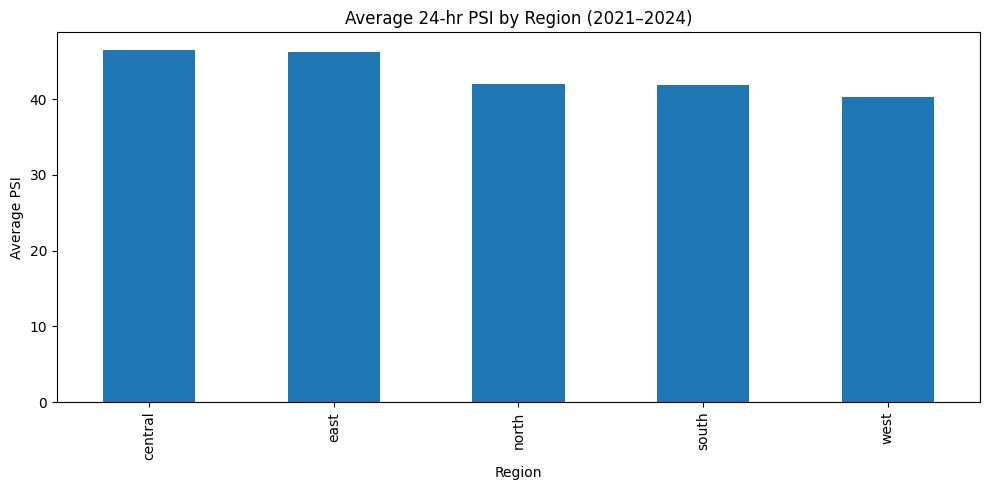

In [ ]:
import matplotlib.pyplot as plt

psi[psi['region'] != 'national'].groupby('region')['psi_twenty_four_hourly'].mean().plot(
    kind='bar', figsize=(10,5),
    title='Average 24-hr PSI by Region (2021–2024)'
)
plt.xlabel('Region')
plt.ylabel('Average PSI')
plt.tight_layout()
plt.show()

The bar chart shows that Central and East consistently record the highest average 24-hour PSI (~46), while  West records are lowest roughly 40.The differences across regions are modest — roughly 6 PSI points separating the highest from the lowest but are consistent and meaningful for our analysis.

 This regional variation justifies our decision to use region-level PSI data rather than a single national average, as it allows us to capture environmental differences across HDB towns.

### Step 7: Monthly trend of PM2.5 by region

While the regional averages above give a useful snapshot, they mask how air quality fluctuates over time. We therefore plot the monthly average PM2.5 by region across 2021–2024 to examine temporal trends and identify any notable spikes or seasonal patterns.

/tmp/ipykernel_596/541953365.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  psi['month'] = pd.to_datetime(psi['timestamp']).dt.to_period('M')


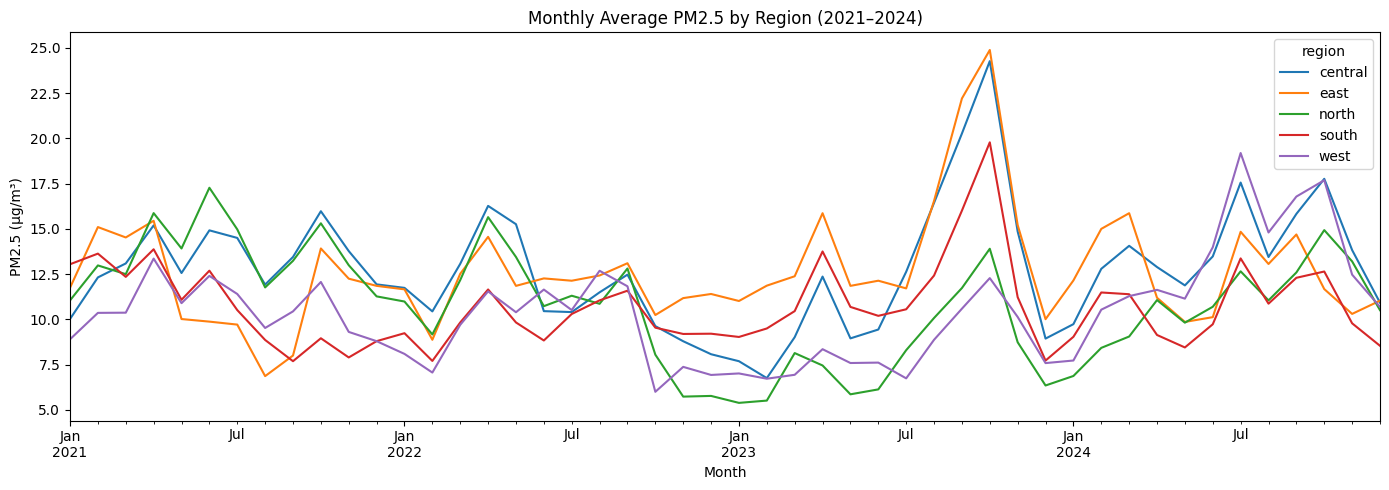

In [ ]:
psi['month'] = pd.to_datetime(psi['timestamp']).dt.to_period('M')

psi[psi['region'] != 'national'].groupby(
    ['month', 'region'])['pm25_twenty_four_hourly'].mean().unstack().plot(
    figsize=(14,5),
    title='Monthly Average PM2.5 by Region (2021–2024)'
)
plt.xlabel('Month')
plt.ylabel('PM2.5 (µg/m³)')
plt.tight_layout()
plt.show()

The line chart reveals a clear spike in PM2.5 levels across all regions around mid-to-late 2023, reaching a peak of approximately 24–25 µg/m³ in the East and Central regions. This corresponds to the severe transboundary haze event in September 2023, caused by forest fires in Indonesia.



Beyond this spike, PM2.5 levels across regions generally track each other closely, with periodic seasonal fluctuations. The **East region consistently trends slightly higher than others across the full period**. This** temporal variation further reinforces the importance of using monthly aggregated PSI/PM2.5** values in our model rather than a static annual average.

##

## Data Quality Assessment

**Positively assessed** — Completeness of core indicators: The two columns most critical to our analysis — pm25_twenty_four_hourly and psi_twenty_four_hourly — have a missing rate of approximately 5%, which is acceptably low. The available readings span all five regions consistently across four years, giving sufficient coverage for monthly aggregation. As the dataset is sourced from data.gov.sg, Singapore's official open data portal, it is expected to meet high standards of accuracy and reliability.

**Problematically assessed** — **Entirely empty column and excessive granularity:** The psi_three_hourly column is completely null across all 202,158 rows, rendering it unusable and requiring removal during data structuring. Additionally, co_eight_hour_max has approximately 41,087 missing values (~20%), significantly higher than other pollutant columns, suggesting inconsistent measurement coverage for carbon monoxide.

Beyond missing values, the dataset is recorded at hourly intervals which is far more granular than needed for our monthly-level analysis and **will require aggregation during data structuring **before it can be joined with the resale dataset.

## Conclusion

The combined PSI dataset (DS2–DS5) is well-suited for our analysis, providing consistent region-level air quality readings across our target period of 2021–2024. Key points for subsequent steps:

**Data Structuring:**

* Convert date column from string to datetime format
* Aggregate hourly readings to monthly mean PM2.5 and PSI values per region
* Filter out national aggregate rows, retaining only the five regional readings
* Drop columns with no analytical value: psi_three_hourly (entirely null), region_id, timestamp, update_timestamp, location_longitude and location_latitude




**Data Enriching:**
* The cleaned monthly PSI table will be joined to the HDB resale dataset by matching region and year-month, tagging each resale transaction with the corresponding air quality reading for its region during that period

**Notable observation:**

* The significant PM2.5 spike in mid-2023 (transboundary haze event) is a notable feature that may have an outsized influence on model results and should be acknowledged during analysis

## DS6: Singapore Train Station Coordinates

**Description:**
This dataset was sourced from Kaggle and contains the coordinates of MRT and LRT stations across Singapore. It includes the station name, type (MRT/LRT), latitude and longitude. This directly addresses our requirement for MRT and LRT station locations, which we will use to compute the distance from each HDB town to its nearest train station as a proxy for accessibility.

### Step 1: Load and preview the dataset

We first load the train station dataset and preview the first few rows to understand its structure and confirm that the data has been imported correctly. The dataset contains the station name, station type (MRT or LRT), and geographical coordinates (latitude and longitude) of train stations across Singapore.

In [ ]:
# Load dataset
mrt = pd.read_csv('/content/mrt_lrt_data.csv')

# Preview top 5 rows
mrt.head()

,station_name,type,lat,lng
0,Jurong East,MRT,1.333207,103.742308
1,Bukit Batok,MRT,1.349069,103.749596
2,Bukit Gombak,MRT,1.359043,103.751863
3,Choa Chu Kang,MRT,1.385417,103.744316
4,Yew Tee,MRT,1.397383,103.747523


Next, we examine the dataset structure to understand the number of rows, columns, and data types.

### Step 2: Check shape and column info

In [ ]:
mrt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   station_name  157 non-null    object 
 1   type          157 non-null    object 
 2   lat           157 non-null    float64
 3   lng           157 non-null    float64
dtypes: float64(2), object(2)
memory usage: 5.0+ KB


The dataset contains 157 entries and 4 columns, including the station name, type, and geographic coordinates. The latitude and longitude columns are stored as float values, while station_name and type are categorical variables stored as object types.

This confirms that the dataset provides the required spatial information needed to calculate distances between HDB towns and nearby train stations. Next, we check for missing values to ensure data completeness.

### Step 3: Check for missing values

In [ ]:
mrt.isnull().sum()

,0
station_name,0
type,0
lat,0
lng,0


The results show that all columns contain zero missing values, indicating that the dataset is complete. This ensures that the coordinates for all train stations are available for distance calculations without requiring additional data cleaning.

### Step 4: Cardinalities — distinct values per column

In [ ]:
mrt.nunique()

,0
station_name,157
type,2
lat,155
lng,156


The dataset contains 157 unique station names, representing MRT and LRT stations across Singapore. The type column contains two categories (MRT and LRT), confirming that the dataset includes both major rail systems.

The latitude and longitude columns contain a large number of unique values, which is expected for geographic coordinate data.

### Step 5: Summary statistics

In [ ]:
mrt.describe()

,lat,lng
count,157.000000,157.000000
mean,1.345080,103.841362
std,0.044289,0.068544
min,1.265453,103.636866
25%,1.308474,103.790046
50%,1.337649,103.851550
75%,1.384116,103.893133
max,1.449133,103.988487




The summary statistics show that the latitude values range from approximately 1.265 to 1.449, while longitude values range from about 103.637 to 103.988. These ranges correspond to the geographical boundaries of Singapore.

This confirms that the coordinates accurately represent train station locations across the island and can be used to compute the distance between HDB towns and their nearest MRT or LRT stations

### Step 6: Distribution of stations by type (MRT vs LRT)

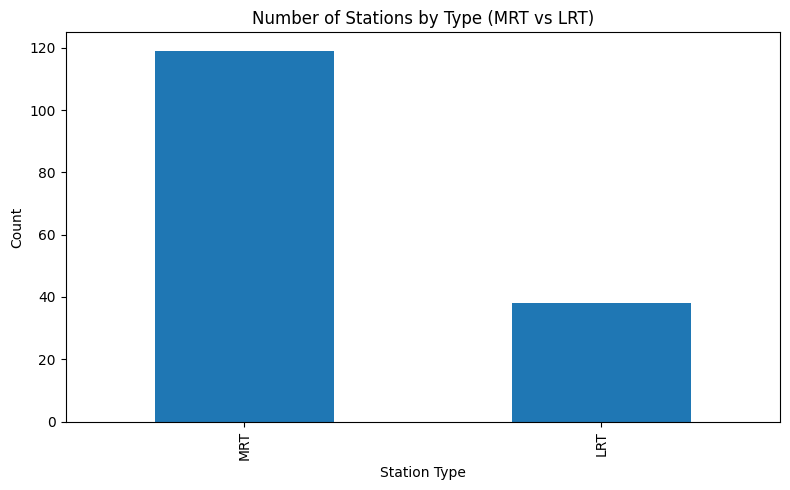

In [ ]:
mrt['type'].value_counts().plot(
    kind='bar', figsize=(8,5),
    title='Number of Stations by Type (MRT vs LRT)'
)
plt.xlabel('Station Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### Step 7: Visualise station locations on a scatter plot

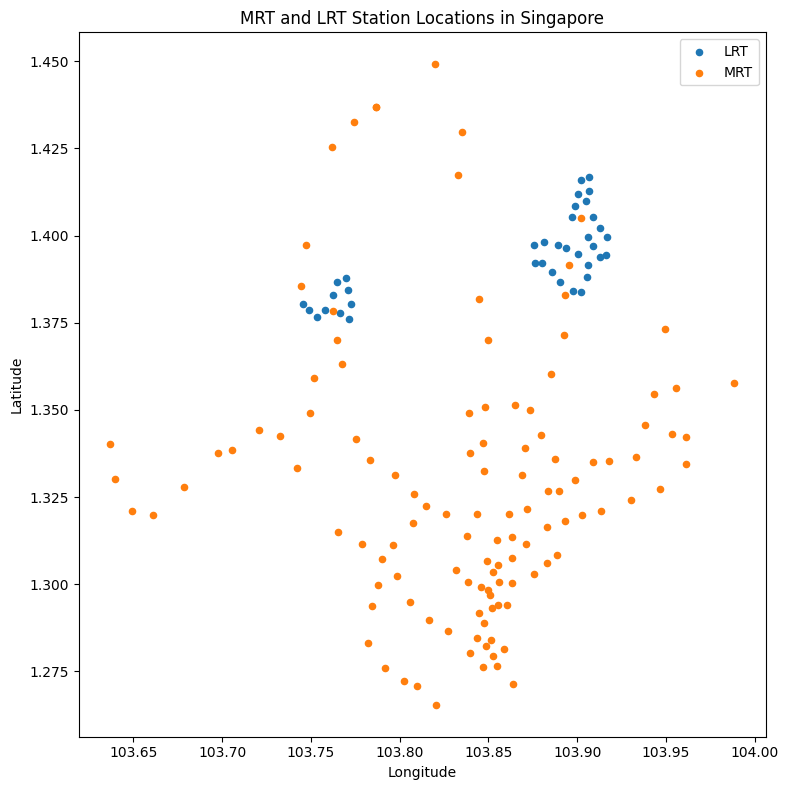

In [ ]:
plt.figure(figsize=(8,8))
for stype, group in mrt.groupby('type'):
    plt.scatter(group['lng'], group['lat'], label=stype, s=20)

plt.title('MRT and LRT Station Locations in Singapore')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.tight_layout()
plt.show()

To complement the type distribution above, we plot the geographical locations of all MRT and LRT stations across Singapore. The scatter plot confirms that MRT stations (orange) are spread across the entire island, while LRT stations (blue) are clustered in three distinct areas — the north-east (Sengkang and Punggol) and the west (Bukit Panjang)

The overall spread of stations across Singapore's geographic bounds gives us confidence that most HDB towns will have at least one station within a reasonable distance, making dist_to_nearest_mrt a meaningful and computable feature for our analysis.

## Data Quality Assessment

**Positively assessed** — Completeness and coordinate accuracy: The dataset contains 157 entries with no missing values across all columns. Coordinate values fall entirely within Singapore's geographic bounds, making the dataset immediately usable for distance computation without any imputation or correction. As a widely used spatial reference for Singapore's train network, the dataset is reliable for transportation accessibility analysis.

**Problematically assessed** — Duplicate coordinates for interchange stations and non-official source: A small number of stations share identical or near-identical coordinates, corresponding to interchange stations that are physically co-located but listed as separate entries. If not handled carefully, this could result in double-counting during distance calculations. Additionally, as the dataset is sourced from Kaggle rather than an official government portal, there is a risk that the station list may not fully reflect the most current network — newer stations opened after the dataset's creation may be absent.

## Conclusion

DS6 is highly suitable for our analysis with minimal preparation needed. Key points for subsequent steps:

**Data Structuring:**

Deduplicate stations with identical coordinates to avoid double-counting interchange stations


**Data Enriching:**

Coordinates will be used alongside DS9 town centroids to compute **dist_to_nearest_mrt** per town using the Haversine formula
Both MRT and LRT stations will be treated equally as transit access points since both contribute to overall public transport accessibility

## DS7: Hospitals with Coordinates

**Description:**
This dataset was sourced from Kaggle and contains hospital names, addresses, postal codes, hospital type (public/private), latitude, longitude and town. This directly addresses our requirement for hospital locations, which we will use to compute the distance from each HDB town to its nearest hospital as a measure of healthcare accessibility.

### Step 1: Load and preview

We first load the hospital dataset and preview the first few rows to understand its structure and confirm that the data has been imported correctly. The dataset contains information such as hospital name, address, postal code, hospital type (public/private), latitude, longitude, and town. Next, we examine the dataset structure to understand the number of rows, columns, and data types.

In [ ]:
import pandas as pd
hospitals = pd.read_csv('/content/hospitals_with_coordinates.csv')
hospitals.head()

,hospital_name,address,postal_code,hospital_type,latitude,longitude,town
0,Crawfurd Hospital,"19 Adam Road, Singapore 289891",289891,Private,1.326812,103.813328,Bukit Timah
1,Farrer Park Hospital,"1 Farrer Park Station Road, #02-01 Connexion, ...",217562,Private,1.312582,103.853915,Farrer Park
2,Gleneagles Hospital,"6A Napier Road, Singapore 258500",258500,Private,1.307378,103.819861,Tanglin
3,Mount Alvernia Hospital,"820 Thomson Road, Singapore 574623",574623,Private,1.341637,103.837264,Marymount
4,Mount Elizabeth Hospital,"3 Mount Elizabeth, Mount Elizabeth Hospital, S...",228510,Private,1.305255,103.835490,Orchard


### Step 2: Shape and column info

In [ ]:
hospitals.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   hospital_name  24 non-null     object 
 1   address        24 non-null     object 
 2   postal_code    24 non-null     int64  
 3   hospital_type  24 non-null     object 
 4   latitude       24 non-null     float64
 5   longitude      24 non-null     float64
 6   town           24 non-null     object 
dtypes: float64(2), int64(1), object(4)
memory usage: 1.4+ KB


The dataset contains 24 entries and 7 columns. Geographic coordinates (latitude and longitude) are stored as float values, while hospital_name, address, hospital_type, and town are stored as object types. The postal_code column is stored as an integer.

This confirms that the dataset provides the spatial information needed to calculate the distance between HDB towns and nearby hospitals.

### Step 3: Missing values

In [ ]:
hospitals.isnull().sum()

,0
hospital_name,0
address,0
postal_code,0
hospital_type,0
latitude,0
longitude,0
town,0


The results show that all columns contain zero missing values, indicating that the dataset is complete. This ensures that the hospital locations and coordinates are available for potential distance calculations.

### Step 4: Cardinalities

In [ ]:
hospitals.nunique()

,0
hospital_name,24
address,23
postal_code,23
hospital_type,2
latitude,23
longitude,23
town,20


There are 24 unique hospital names but only 23 unique addresses, postal codes, latitude and longitude values, suggesting one pair of hospitals may share the same location — likely a hospital complex housing multiple institutions. There are only 2 hospital types (Public and Private) and 20 unique towns, meaning many HDB towns have no hospital within their boundaries at all. To better understand the type breakdown, we visualise the distribution of hospitals by type.

### Step 5: Distribution by hospital type

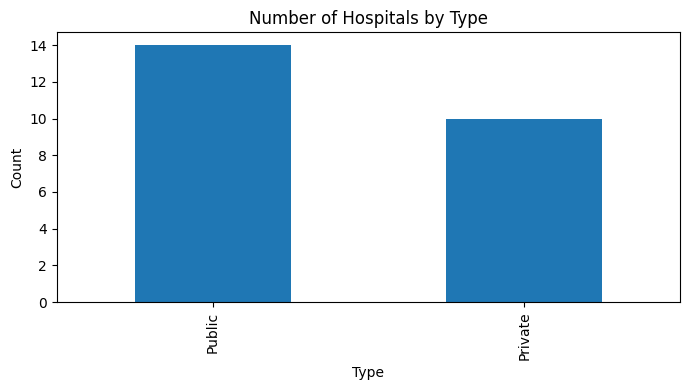

In [ ]:
import matplotlib.pyplot as plt

hospitals['hospital_type'].value_counts().plot(
    kind='bar',
    figsize=(7,4),
    title='Number of Hospitals by Type'
)

plt.xlabel('Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

The bar chart shows that there are 14 public hospitals and 10 private hospitals in Singapore. While public hospitals are more numerous, both types are geographically sparse  with only 24 hospitals across the entire island. To understand whether these hospitals are evenly spread or concentrated in certain areas, we plot their locations across Singapore.

### Step 6: Hospital locations across Singapore

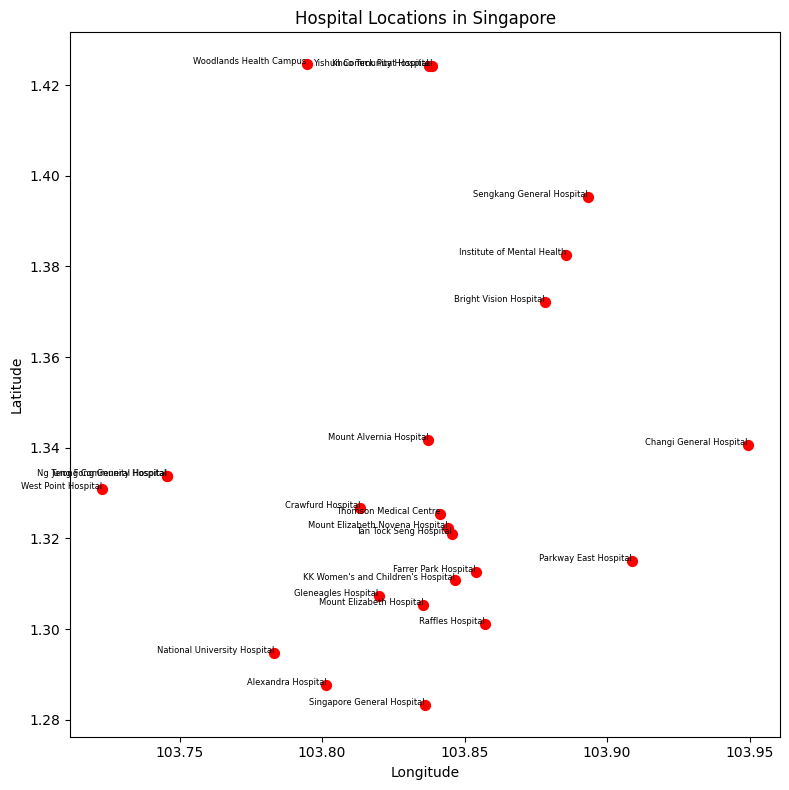

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))
plt.scatter(hospitals['longitude'], hospitals['latitude'], s=50, color='red')

for i, row in hospitals.iterrows():
    plt.annotate(row['hospital_name'], (row['longitude'], row['latitude']),
                 fontsize=6, ha='right')

plt.title('Hospital Locations in Singapore')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.show()

The scatter plot reveals a critical limitation of this dataset  the vast majority of hospitals are clustered in the central region of Singapore, particularly around the Orchard, Novena and Bukit Timah areas. Only a handful of hospitals are located in the north (Woodlands, Yishun) and east (Changi, Sengkang), with very few in the west.

 This highly uneven geographic distribution means that most HDB towns, particularly in the west and north-east, would map to the same few hospitals when computing nearest-hospital distance, resulting in minimal variation in the *dist_to_nearest_hospital* feature across towns. These observations raise significant concerns about the suitability of this dataset for our analysis, which we now assess formally.

### Data Quality

**Positively assessed** — Completeness and coordinate accuracy: The dataset is fully complete with no missing values across all 24 entries. Coordinate values fall within Singapore's geographic bounds and town assignments appear accurate, making it technically ready for distance computation without any cleaning required.

**Problematically assessed** — Insufficient size and geographic concentration: With only 24 hospitals in total, the dataset is far too small to generate a meaningful and discriminatory distance feature. The heavy geographic concentration of hospitals in the central region further compounds this issue.

The computed distance to nearest hospital would show very little variation across HDB towns, providing minimal explanatory power in our regression model compared to MRT stations (157 entries, island-wide) or schools (337 entries across all regions).

## Conclusion

We disregard DS7 from further consideration after careful exploration. Despite being clean and complete, the dataset's small size of only 24 hospitals and their heavy concentration in central Singapore means that **dist_to_nearest_hospital** would exhibit very little variation across HDB towns. This severely limits its usefulness as an explanatory variable in our regression model, adding pipeline complexity without meaningful analytical benefit.

## DS8: General Information of Schools

**Description:**
This dataset was extracted from Singapore's open data portal, data.gov.sg, and contains general information on all schools in Singapore, including school name, address, postal code, zone, type, and nearest MRT station. This addresses our requirement for school locations across Singapore as a measure of education accessibility.

Unlike the hospital and MRT datasets, this dataset does not contain latitude and longitude coordinates. However, rather than geocoding postal codes using an external API which adds unnecessary complexity and potential errors. We will instead use the *dgp_code* column, which maps each school directly to its town (e.g. Woodlands, Yishun, Bishan).



 Since our resale price analysis operates at the town level, this approach is not only simpler but also more appropriate, as it allows us to directly **count the number of schools per town** as our accessibility measure. The zone_code column (North/South/East/West/Central) further allows us to cross-reference with our PSI regional data.


 All other irrelevant columns such as telephone, fax, URL and session code will be dropped during data structuring.

### Step 1: Load and preview

We first load the schools dataset and preview the first few rows to understand its structure and confirm that the data has been imported correctly.

In [ ]:
schools = pd.read_csv('/content/General_Information_of_Schools.csv')
schools.head()

,school_name,url_address,address,postal_code,telephone_no,telephone_no_2,fax_no,fax_no_2,mrt_desc,bus_desc,...,nature_code,session_code,mainlevel_code,sap_ind,autonomous_ind,gifted_ind,ip_ind,mothertongue1_code,mothertongue2_code,mothertongue3_code
0,ADMIRALTY PRIMARY SCHOOL,https://admiraltypri.moe.edu.sg/,11 WOODLANDS CIRCLE,738907,63620598,na,63627512,na,Admiralty Station,"TIBS 965, 964, 913",...,CO-ED SCHOOL,FULL DAY,PRIMARY,No,No,No,No,CHINESE,MALAY,TAMIL
1,ADMIRALTY SECONDARY SCHOOL,http://www.admiraltysec.moe.edu.sg,31 WOODLANDS CRESCENT,737916,63651733,63654596,63652774,na,ADMIRALTY MRT,904,...,CO-ED SCHOOL,SINGLE SESSION,SECONDARY (S1-S5),No,No,No,No,CHINESE,MALAY,TAMIL
2,AHMAD IBRAHIM PRIMARY SCHOOL,http://www.ahmadibrahimpri.moe.edu.sg,10 YISHUN STREET 11,768643,67592906,na,67592927,na,Yishun,Yishun Ring Road - 812 (white plate); Yishun A...,...,CO-ED SCHOOL,SINGLE SESSION,PRIMARY,No,No,No,No,CHINESE,MALAY,TAMIL
3,AHMAD IBRAHIM SECONDARY SCHOOL,http://www.ahmadibrahimsec.moe.edu.sg,751 YISHUN AVENUE 7,768928,67585384,na,67557778,na,"CANBERRA MRT, YISHUN MRT","117, 167, 169, 800, 811, 812, 883, 856, 858, 8...",...,CO-ED SCHOOL,SINGLE SESSION,SECONDARY (S1-S5),No,No,No,No,CHINESE,MALAY,TAMIL
4,AI TONG SCHOOL,http://www.aitong.moe.edu.sg,100 Bright Hill Drive,579646,64547672,na,64532726,na,Bishan MRT,"410, 162, 52",...,CO-ED SCHOOL,SINGLE SESSION,PRIMARY,Yes,No,No,No,CHINESE,na,na


The dataset contains information such as school name, address, postal code, zone, type, and nearest MRT station, along with several administrative attributes.

### Step 2: Shape and column info

In [ ]:
schools.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 337 entries, 0 to 336
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   school_name         337 non-null    object
 1   url_address         337 non-null    object
 2   address             337 non-null    object
 3   postal_code         337 non-null    int64 
 4   telephone_no        337 non-null    object
 5   telephone_no_2      337 non-null    object
 6   fax_no              337 non-null    object
 7   fax_no_2            337 non-null    object
 8   mrt_desc            337 non-null    object
 9   bus_desc            337 non-null    object
 10  dgp_code            337 non-null    object
 11  zone_code           337 non-null    object
 12  type_code           337 non-null    object
 13  nature_code         337 non-null    object
 14  session_code        337 non-null    object
 15  mainlevel_code      337 non-null    object
 16  sap_ind             337 no

The dataset contains 337 entries and 23 columns, with most variables stored as object types representing categorical or administrative information. The postal_code column is stored as an integer, while other fields such as dgp_code, zone_code, and type_code provide location and classification details for each school.

This confirms that the dataset provides sufficient information to identify school distribution across different towns and regions in Singapore.

### Step 3: Missing values

In [ ]:
schools.isnull().sum()

,0
school_name,0
url_address,0
address,0
postal_code,0
telephone_no,0
telephone_no_2,0
fax_no,0
fax_no_2,0
mrt_desc,0
bus_desc,0


The results show that all columns contain zero missing values, indicating that the dataset is complete. This ensures that the school information can be used reliably for further analysis.

### Step 4: Cardinalities

In [ ]:
schools.nunique()

,0
school_name,337
url_address,337
address,336
postal_code,335
telephone_no,335
telephone_no_2,18
fax_no,331
fax_no_2,6
mrt_desc,269
bus_desc,327


The dataset contains 337 unique schools across Singapore. The dgp_code column contains 28 unique towns, which aligns well with the town-level structure used in our resale housing dataset.

The zone_code column contains four regional categories (North, South, East, West), which allows the dataset to be linked with regional environmental data such as the PSI dataset. Other variables such as type_code and mainlevel_code classify schools by education level and category.

However, it is worth noting that several columns such as telephone_no_2 and fax_no_2 show only 18 and 6 unique values respectively in the cardinalities step, suggesting that "na" strings are used as placeholders rather than actual null values. Since these columns will be dropped entirely during structuring, this does not affect our analysis.To better understand the geographic spread of schools, we visualise the distribution by zone.

### Step 5: Distribution of schools by zone

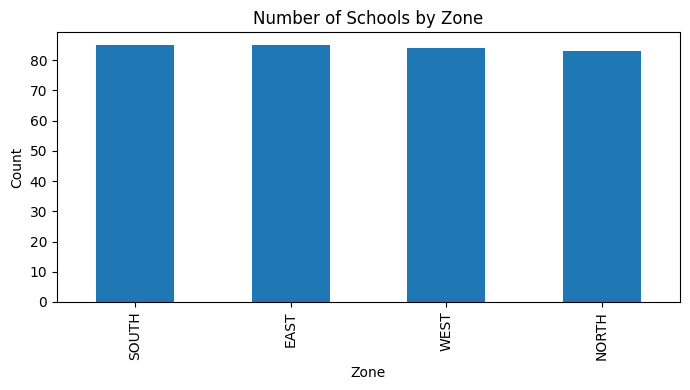

In [ ]:
schools['zone_code'].value_counts().plot(kind='bar', figsize=(7,4),
    title='Number of Schools by Zone')
plt.xlabel('Zone'); plt.ylabel('Count')
plt.tight_layout(); plt.show()

The bar chart shows a remarkably even distribution of schools across all four zones South (roughly 85), East (roughly 85), West (roughly 83) and North (roughly 82)  with each zone hosting approximately the same number of schools. This is in stark contrast to the hospital dataset (DS7), where institutions were heavily concentrated in the central region

The even geographic spread of schools across Singapore gives us confidence that **number_of_schools_per_town** will show meaningful variation across HDB towns, making it a more discriminatory and analytically useful accessibility feature than hospital distance.

###  Step 6:Number of schools per town


To understand how school distribution varies at the town level, we plot the number of schools per town using the **dgp_code** column.

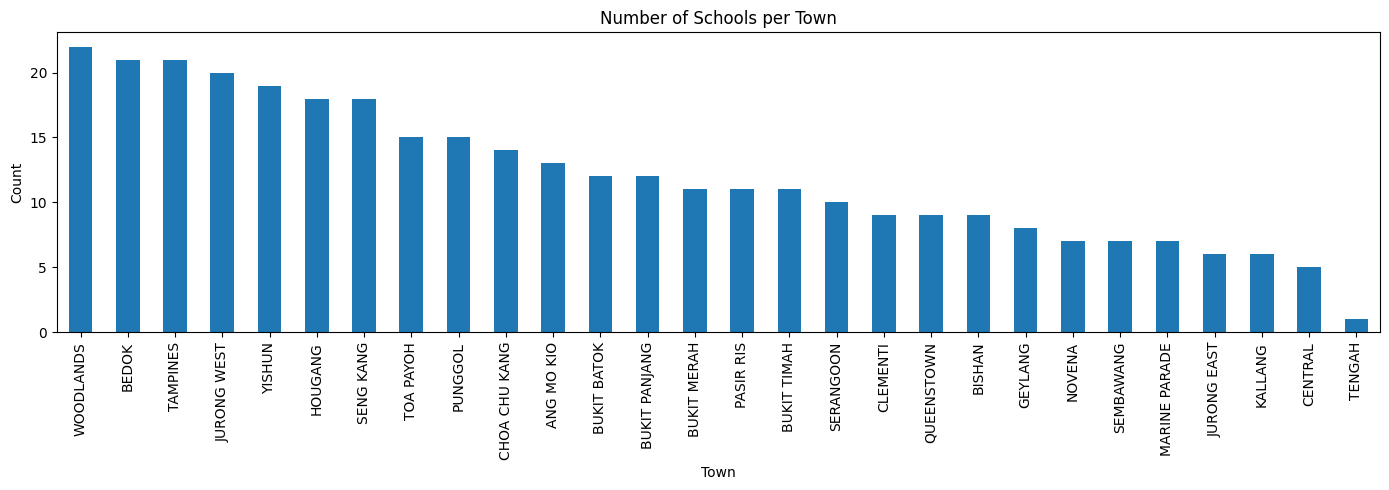

In [ ]:
schools['dgp_code'].value_counts().plot(
    kind='bar', figsize=(14,5),
    title='Number of Schools per Town'
)
plt.xlabel('Town')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

The bar chart reveals clear variation across towns — Woodlands (22), Bedok (21) and Tampines (21) have the highest number of schools, while Tengah (1), Central (5) and Kallang (6) have the fewest. This meaningful variation across 28 towns confirms that school_count will serve as a useful and discriminatory accessibility feature in our regression model.

Larger towns with higher residential populations naturally tend to have more schools, which also aligns with our expectation that school accessibility may correlate with HDB resale prices in those areas

## Data quality

**Positively assessed** — Geographic coverage and even distribution: With 337 schools spread evenly across 28 towns and 4 zones, this dataset provides excellent geographic coverage for our town-level analysis. The even distribution ensures that the school_count feature will vary meaningfully across HDB towns, providing genuine explanatory power in our regression model. As the dataset is sourced from data.gov.sg, it meets high standards of accuracy and reliability.


**Problematically assessed** — Absence of coordinates and placeholder null values: The dataset does not contain latitude and longitude coordinates, unlike DS6 and DS7. While we work around this by using dgp_code for town-level aggregation, this means we cannot compute precise distance-to-nearest-school values and must rely on school count as a proxy instead. Additionally, missing values in columns like telephone_no_2 and fax_no_2 are represented as "na" strings rather than actual null values, meaning standard null-checking methods would not detect them

## Conclusion

DS8 is well-suited for our analysis as a measure of education accessibility at the town level. Key points for subsequent steps:


**Data Structuring:**
* Drop irrelevant columns: **url_address, telephone_no, telephone_no_2, fax_no, fax_no_2, bus_desc, session_code, sap_ind, autonomous_ind, gifted_ind, ip_ind, mothertongue1_code, mothertongue2_code, mothertongue3_code**
* Retain key columns: **school_name, dgp_code, zone_code, mainlevel_code**
* Group by dgp_code to count the number of schools per town, generating a school_count feature

**Data Enriching:**
* The school_count per town will be joined to the HDB resale dataset by matching on town, adding education accessibility as an explanatory variable in our regression model


## DS9: Singapore City Geo-Coordinates

**Description:**
This dataset was sourced from Kaggle and contains the latitude and longitude of towns and cities across Singapore, along with their corresponding region (North, South, East, West, Central). This dataset serves as a critical geographic mapping table in our analysis as it allows us to map each HDB town to its coordinates and region, which is essential for linking the resale price data with the PSI air quality data (which is region-based) and for computing distances to amenities.

### Step 1: Load and preview

We first load the Singapore city geo-coordinates dataset and preview the first few rows to understand its structure and confirm that the data has been imported correctly. The dataset contains information such as place name, city (town), region (area), and geographic coordinates (latitude and longitude).

In [ ]:
sg_coords = pd.read_csv('/content/singapore_city_coordinates_improved.csv')
sg_coords.head()

,Place,City,Area,latitude,longitude,bounding_box_1,bounding_box_2,bounding_box_3,bounding_box_4
0,Bishan East,Bishan,central,1.351912,103.848971,1.341685,1.367983,103.818451,103.860476
1,Marymount,Bishan,central,1.348604,103.839393,1.347739,1.349522,103.838921,103.840169
2,Upper Thomson,Bishan,central,1.354639,103.832512,1.353404,1.355813,103.831599,103.834056
3,Alexandra Hill,Bukit Merah,central,1.277477,103.801880,1.257477,1.297477,103.781880,103.821880
4,Alexandra North,Bukit Merah,central,1.277477,103.801880,1.257477,1.297477,103.781880,103.821880


### Step 2: Shape and column info

In [ ]:
sg_coords.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 332 entries, 0 to 331
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Place           332 non-null    object 
 1   City            332 non-null    object 
 2   Area            332 non-null    object 
 3   latitude        315 non-null    float64
 4   longitude       315 non-null    float64
 5   bounding_box_1  315 non-null    float64
 6   bounding_box_2  315 non-null    float64
 7   bounding_box_3  315 non-null    float64
 8   bounding_box_4  315 non-null    float64
dtypes: float64(6), object(3)
memory usage: 23.5+ KB


The dataset contains 332 entries and 9 columns. Geographic coordinates such as latitude and longitude are stored as float values, while variables such as Place, City, and Area are stored as object types representing locations and regions in Singapore.

Additional columns such as bounding_box_1 to bounding_box_4 represent geographic boundary information for each location. However, these bounding box variables are not required for our analysis and will be removed during data structuring.





### Step 3: Missing values

In [ ]:
sg_coords.isnull().sum()

,0
Place,0
City,0
Area,0
latitude,17
longitude,17
bounding_box_1,17
bounding_box_2,17
bounding_box_3,17
bounding_box_4,17


The dataset contains 17 missing values in the coordinate-related columns, including latitude, longitude, and the bounding box variables. Since our analysis requires only the main coordinates for mapping towns, we will retain rows with valid latitude and longitude values and drop unnecessary columns during cleaning

### Step 4: Cardinalities

In [ ]:
sg_coords.nunique()

,0
Place,331
City,55
Area,5
latitude,286
longitude,286
bounding_box_1,285
bounding_box_2,286
bounding_box_3,286
bounding_box_4,286


There are 331 unique Place values out of 332 rows, suggesting one duplicate place name exists. More importantly, the City column has 55 distinct values — representing the broader towns across Singapore and Area has only 5 distinct values (North, South, East, West, Central), which aligns with our PSI regional breakdown.



The 286 unique coordinate pairs compared to 332 rows confirms that multiple sub-areas within the same town share the same or similar coordinates, which is expected given the granularity of the dataset. To verify whether DS9 covers all HDB towns present in our resale dataset, we perform a cross-check.

### Step 5: Check all HDB towns are covered

In [ ]:
# Check which resale towns are missing from sg_coords
resale_towns = set(resale['town'].unique())
coord_towns = set(sg_coords['City'].str.upper().unique())
missing = resale_towns - coord_towns
print(f"Towns in resale not found in DS9: {missing}")

Towns in resale not found in DS9: {'KALLANG/WHAMPOA', 'CENTRAL AREA'}


The cross-check reveals that two towns in the resale dataset are **not found in DS9: KALLANG/WHAMPOA and CENTRAL AREA.** This is a notable data quality issue — these two towns appear in DS1 but cannot be mapped to coordinates using DS9 as-is, which would cause them to be excluded from distance calculations during data enrichment.


During data structuring, we will manually add entries for these two towns with their known approximate coordinates to ensure full coverage of all HDB towns.


### Step 6: Visualise all town coordinates on a scatter plot


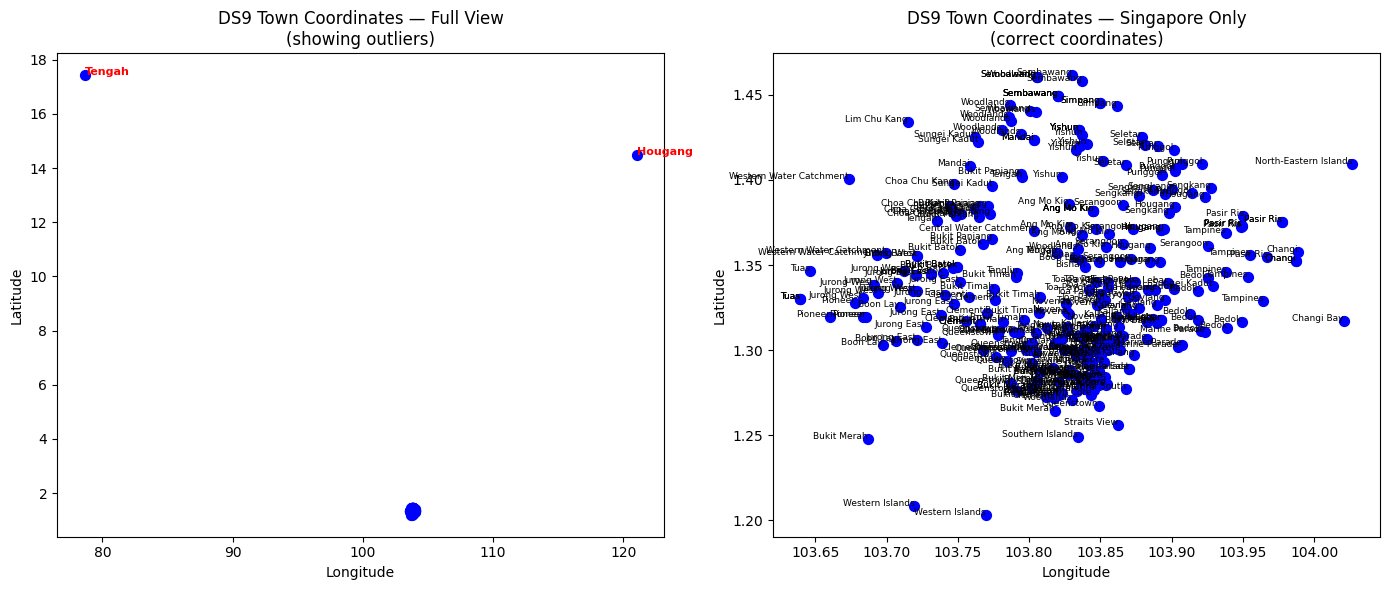

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Full view showing outliers
axes[0].scatter(sg_coords['longitude'], sg_coords['latitude'], s=50, color='blue')
axes[0].set_title('DS9 Town Coordinates — Full View\n(showing outliers)')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
for i, row in sg_coords.iterrows():
    if abs(row['latitude'] - 1.352) > 1 or abs(row['longitude'] - 103.82) > 1:
        axes[0].annotate(row['City'], (row['longitude'], row['latitude']),
                         fontsize=8, color='red', fontweight='bold')

# Plot 2: Zoomed in to Singapore only (correct towns)
sg_only = sg_coords[
    (abs(sg_coords['latitude'] - 1.352) <= 1) &
    (abs(sg_coords['longitude'] - 103.82) <= 1)
]
axes[1].scatter(sg_only['longitude'], sg_only['latitude'], s=50, color='blue')
axes[1].set_title('DS9 Town Coordinates — Singapore Only\n(correct coordinates)')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
for i, row in sg_only.iterrows():
    axes[1].annotate(row['City'], (row['longitude'], row['latitude']),
                     fontsize=6.5, ha='right')

plt.tight_layout()
plt.show()

### Step 7: Identify problematic rows with wrong coordinates

In [ ]:
# Singapore reference coordinate
sg_lat = 1.352083
sg_lon = 103.819836

# rows that are likely problematic (far from Singapore center)
bad_rows = sg_coords[
    (abs(sg_coords['latitude'] - sg_lat) > 1) |
    (abs(sg_coords['longitude'] - sg_lon) > 1)
]

print(bad_rows)

         Place     City        Area   latitude   longitude  bounding_box_1  \
269       Park   Tengah        west  17.428784   78.642148       17.428451   
305  Trafalgar  Hougang  north-east  14.485000  121.022243       14.484983   

     bounding_box_2  bounding_box_3  bounding_box_4  
269       17.429116       78.641945       78.642349  
305       14.485000      121.022243      121.022345  


Inspecting the rows with suspicious coordinates reveals two problematic entries — Tengah (lat: 17.43, lng: 78.64) and Hougang (lat: 14.49, lng: 121.02), which correspond to locations in Hyderabad, India and Manila, Philippines respectively. These are clearly erroneous values, likely introduced during dataset creation. Both will be corrected with their actual Singapore coordinates during data structuring before any distance computation is performed.

## Data Quality

**Positively assessed** — Regional mapping and broad town coverage: The Area column provides clean and consistent region labels (North, South, East, West, Central) across all 332 entries with no missing values, making it immediately usable for linking HDB towns to their corresponding PSI region. With 55 distinct towns covered, the dataset provides broad geographic coverage across Singapore, serving as the critical geographic backbone connecting all other datasets.


**Problematically assessed** — Erroneous coordinates and incomplete town coverage: Two rows contain clearly incorrect coordinates — Tengah and Hougang point to locations in Hyderabad, India and Manila, Philippines respectively, rendering them unusable for distance computation as-is. Additionally, 17 rows have missing latitude and longitude values entirely, and two HDB towns (KALLANG/WHAMPOA and CENTRAL AREA) are absent from DS9 altogether. All three issues must be resolved during data structuring to ensure accurate distance calculations and full town coverage.

## Conclusion


DS9 is essential to our analysis as the geographic backbone that connects all other datasets. Despite the coordinate issues identified, they are resolvable during data structuring. Key points for subsequent steps:

**Data Structuring:**
* Correct erroneous coordinates for Tengah and Hougang with their actual Singapore coordinates
* Drop rows with missing latitude and longitude values
* Drop bounding box columns as they are not needed
* Manually add entries for KALLANG/WHAMPOA and CENTRAL AREA with their known approximate coordinates
* Group by City and compute mean latitude and longitude per town to obtain a single centroid coordinate per town

**Data Enriching:**

* Town centroid coordinates will be used alongside DS6 to compute dist_to_nearest_mrt per town using the Haversine formula
* The Area column will be used to map each HDB town to its corresponding PSI region from DS2–DS5, linking air quality data to resale transactions
* School count per town from DS8 will be joined by town name to add education accessibility as an explanatory variable





## Data Preparation (Process)

*In this section, describe, justify, and implement transoformation and profiling tasks to prepare the data you have selected for later analysis. Structure the section as follows:

Overview: provides a summary of the transformations performed, reffering to the specific types of operations discussed in class. Should include a visualization of the transformation pipeline.
For each individual operation (task), briefly describe what it does using terms defined in class, why you perform it, and implement it.